In [1]:
import os
import numpy as np
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from scipy.signal import welch

No_aces

In [2]:
no_aces = "C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed"
print(os.path.exists(no_aces))

True


In [3]:
files = glob.glob(os.path.join(no_aces, "*AveOverTrials.txt"))

fs = 500  

In [4]:
all_subject_psd = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd))

Subjects: 47


In [5]:
all_subject_psd = []
freqs = None

for f in files:

    data = np.genfromtxt(f, skip_header=1)

    time = data[:,0]
    signals = data[:,1:]

    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # average electrodes → one PSD per participant
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd))


Subjects: 47


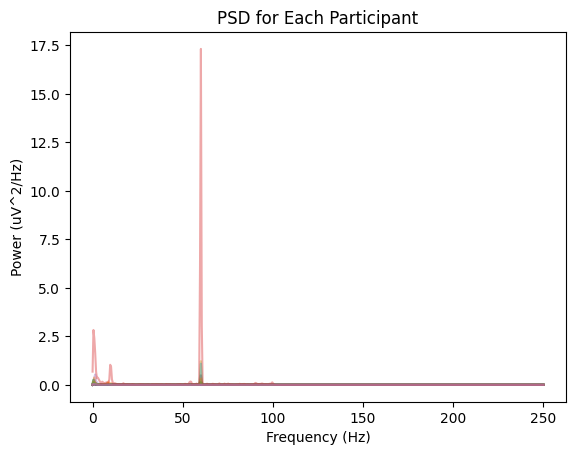

In [6]:
for subj_psd in all_subject_psd:
    plt.plot(freqs, subj_psd, alpha=0.4)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (uV^2/Hz)")
plt.title("PSD for Each Participant")
plt.show()

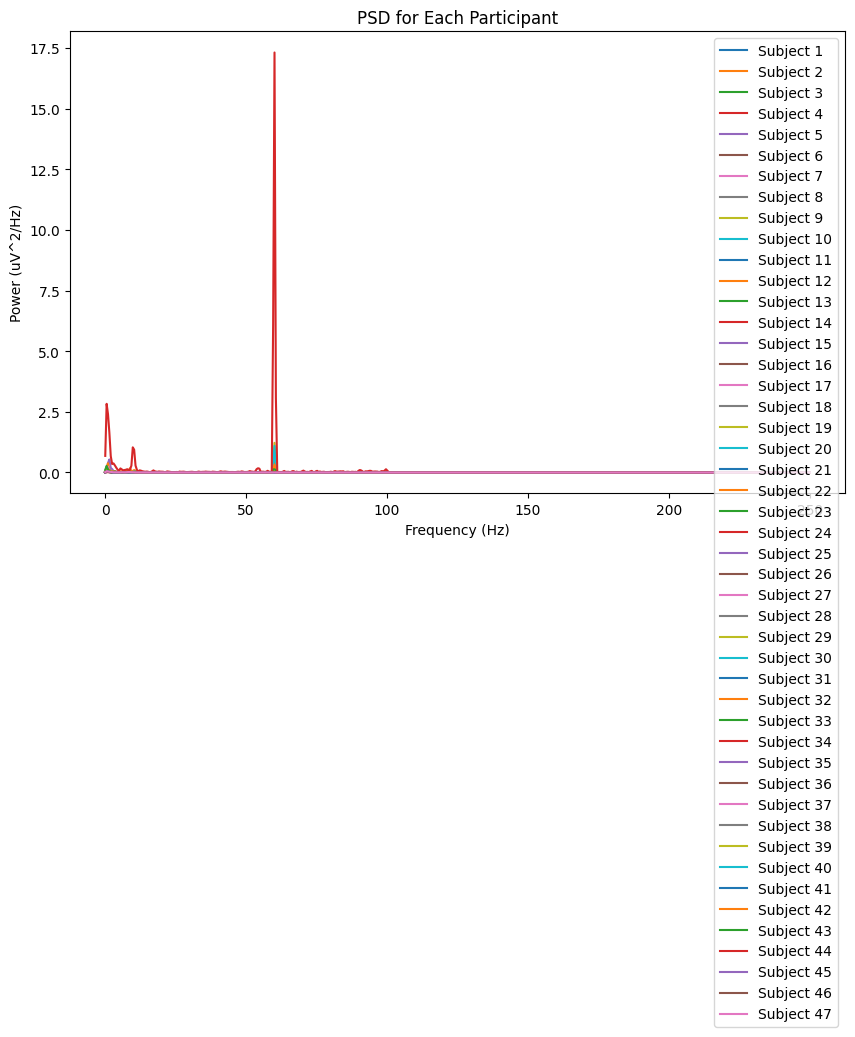

In [7]:
plt.figure(figsize=(10,6))

for i, subj_psd in enumerate(all_subject_psd):
    plt.plot(freqs, subj_psd, label=f"Subject {i+1}")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (uV^2/Hz)")
plt.title("PSD for Each Participant")
plt.legend()
plt.show()

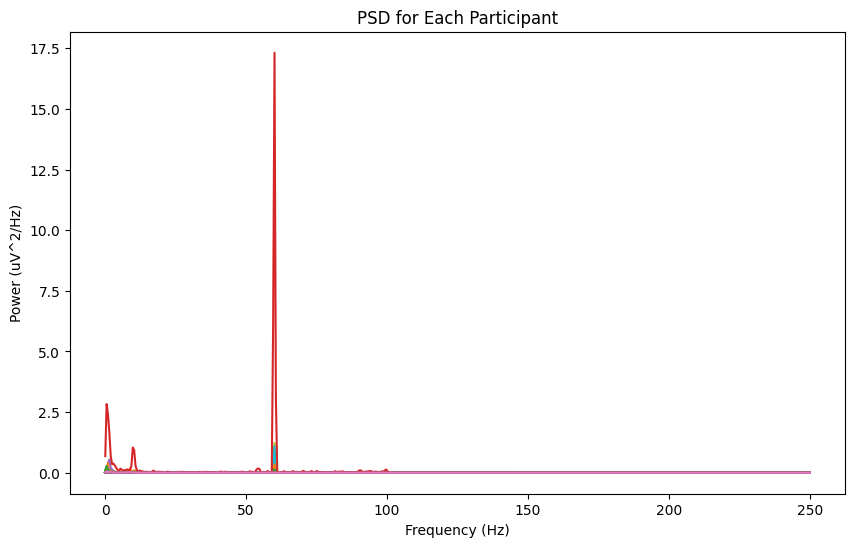

In [8]:
plt.figure(figsize=(10,6))

for subj_psd in all_subject_psd:
    plt.plot(freqs, subj_psd)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (uV^2/Hz)")
plt.title("PSD for Each Participant")
plt.show()

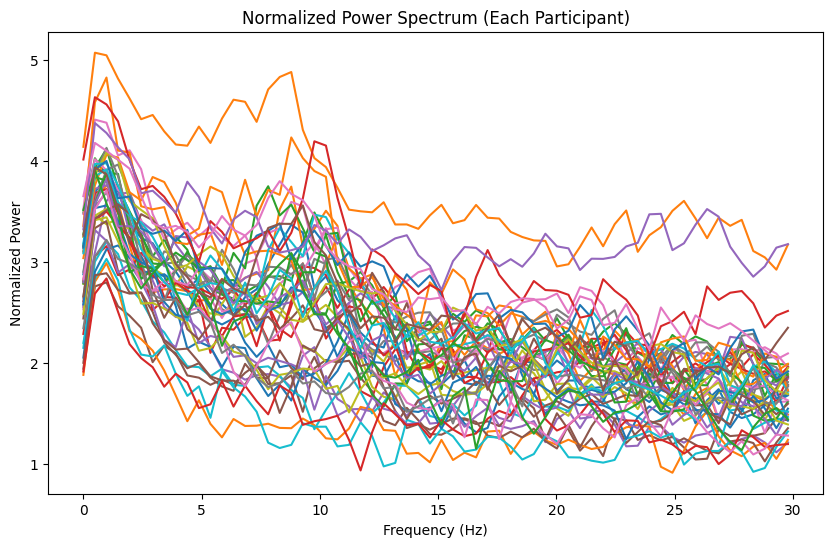

In [9]:
alpha_mask = (freqs >= 0) & (freqs <= 30)

plt.figure(figsize=(10,6))

for subj_psd in all_subject_psd:

    eps = 1e-12
    log_psd = np.log10(subj_psd + eps)

    # baseline = mean across all frequencies
    baseline = np.mean(log_psd)
    log_psd_norm = log_psd - baseline

    plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Normalized Power Spectrum (Each Participant)")
plt.show()

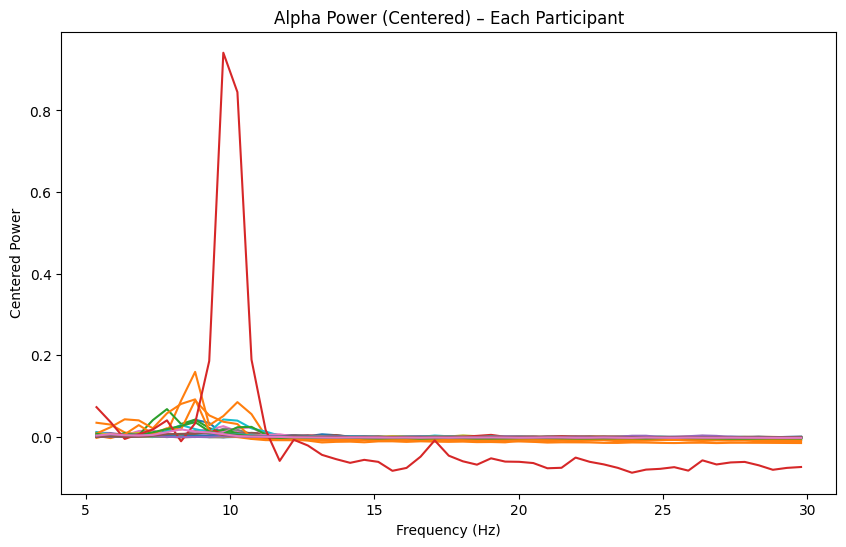

In [10]:
alpha_mask = (freqs >= 5) & (freqs <= 30)

plt.figure(figsize=(10,6))

for subj_psd in all_subject_psd:

    alpha_power = subj_psd[alpha_mask]
    alpha_power_centered = alpha_power - np.mean(alpha_power)

    plt.plot(freqs[alpha_mask], alpha_power_centered)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Alpha Power (Centered) – Each Participant")
plt.show()

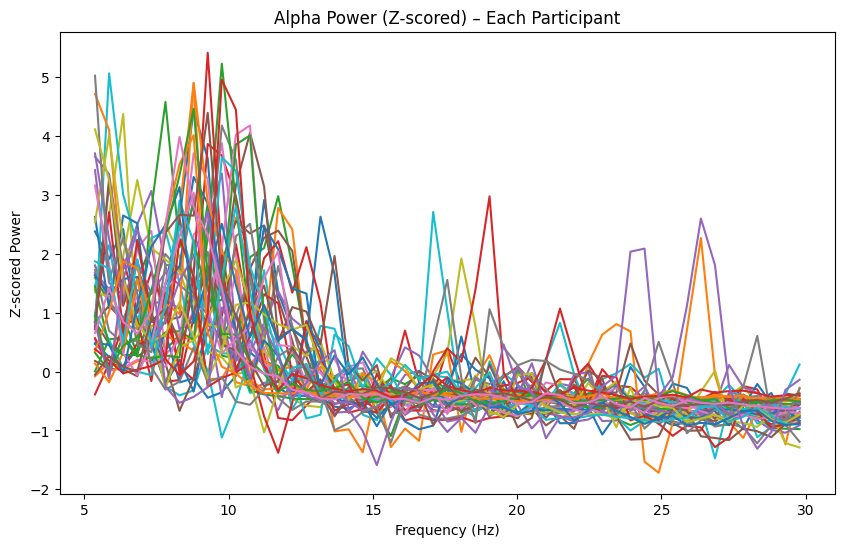

In [11]:
plt.figure(figsize=(10,6))

for subj_psd in all_subject_psd:

    alpha_power = subj_psd[alpha_mask]
    alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

    plt.plot(freqs[alpha_mask], alpha_power_z)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Alpha Power (Z-scored) – Each Participant")
plt.show()

In [12]:
from scipy import stats

In [13]:
alpha_mask = (freqs >= 5) & (freqs <= 30)

# frequencies where we want error bars
target_freqs = [8, 10, 12]

means = []
cis = []

for f in target_freqs:

    # find closest frequency index
    idx = np.argmin(np.abs(freqs - f))

    # collect power from every participant at that frequency
    values = np.array([subj[idx] for subj in all_subject_psd])

    mean = np.mean(values)
    sem = stats.sem(values)

    # 95% confidence interval
    ci = sem * stats.t.ppf((1 + 0.65) / 2., len(values)-1)

    means.append(mean)
    cis.append(ci)

In [14]:
all_subject_psd = np.vstack(all_subject_psd)

group_psd = np.mean(all_subject_psd, axis=0)

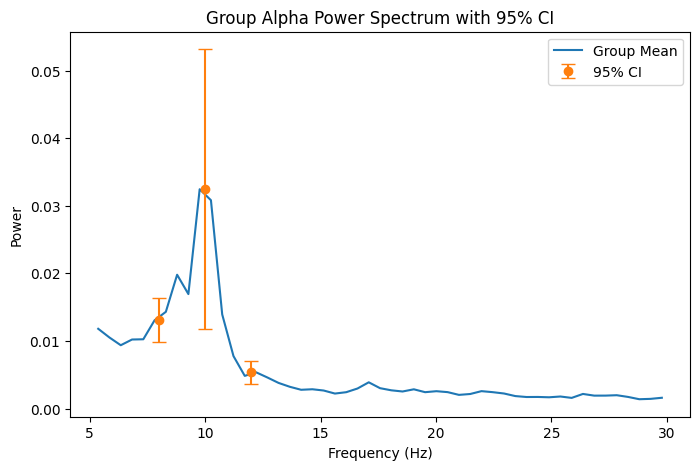

In [15]:
plt.figure(figsize=(8,5))

# group line
plt.plot(freqs[alpha_mask], group_psd[alpha_mask], label="Group Mean")

# error bars
plt.errorbar(target_freqs, means, yerr=cis, fmt='o', capsize=5, label="95% CI")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum with 95% CI")
plt.legend()
plt.show()

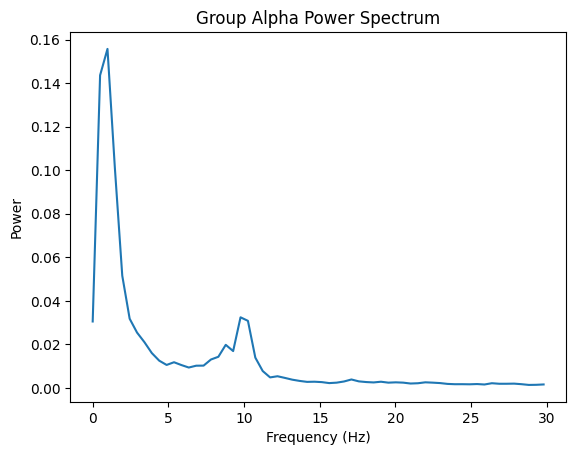

In [16]:
import matplotlib.pyplot as plt

alpha_mask = (freqs >= 0) & (freqs <= 30)

plt.plot(freqs[alpha_mask], group_psd[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

## Better Version No_aces

In [17]:
eps = 1e-12
log_psd = np.log10(group_psd + eps)

In [18]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm = log_psd - baseline

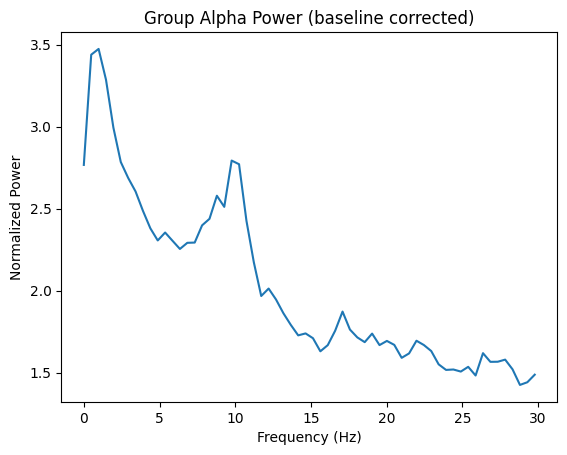

In [19]:

plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

### Z-Score

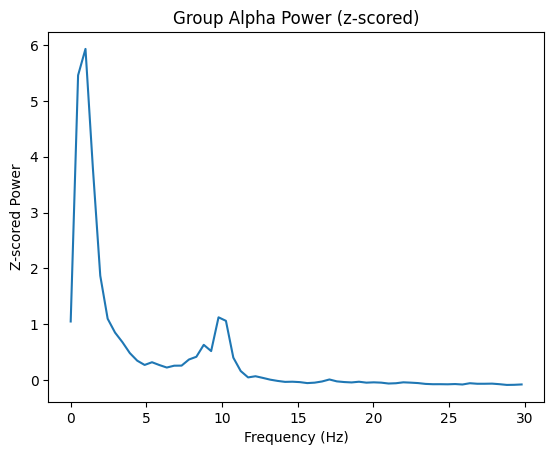

In [20]:
psd_mean = np.mean(group_psd)
psd_std = np.std(group_psd)
psd_z = (group_psd - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# 2nd Better Version No_ACEs

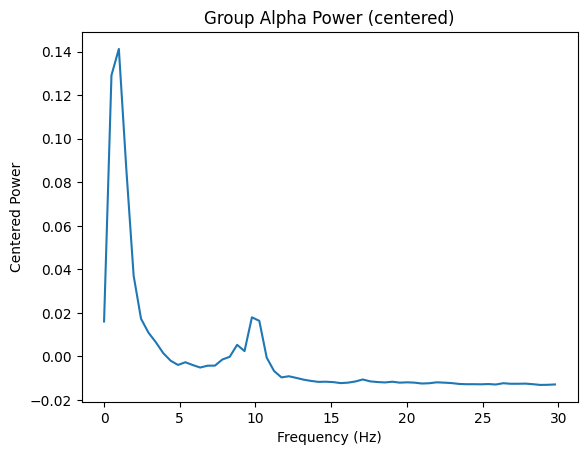

In [21]:


alpha_power = group_psd[alpha_mask]
alpha_power_centered = alpha_power - np.mean(alpha_power)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

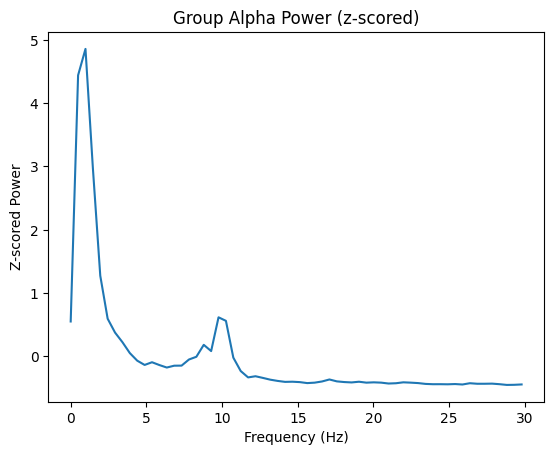

In [22]:
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

plt.plot(freqs[alpha_mask], alpha_power_z)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# ACES

In [23]:
aces = "C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed\\EC_ACES"
print(os.path.exists(aces))

True


In [24]:
files = glob.glob(os.path.join(aces, "*AveOverTrials.txt"))

fs = 500   

In [25]:
all_subject_psd = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd))

Subjects: 151


In [26]:
all_subject_psd = []
freqs = None


for f in files:


    data = np.genfromtxt(f, skip_header=1)


    time = data[:,0]
    signals = data[:,1:]


    elec_psds = []


    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)


    elec_psds = np.array(elec_psds)


    # average electrodes → one PSD per participant
    mean_psd = np.mean(elec_psds, axis=0)


    all_subject_psd.append(mean_psd)


    if freqs is None:
        freqs = f_psd


print("Subjects:", len(all_subject_psd))

Subjects: 151


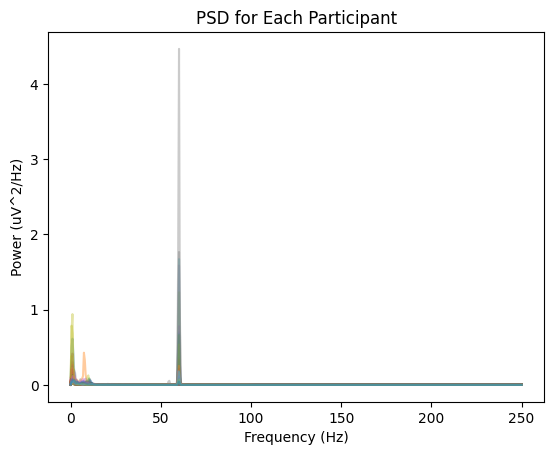

In [27]:
for subj_psd in all_subject_psd:
    plt.plot(freqs, subj_psd, alpha=0.4)


plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (uV^2/Hz)")
plt.title("PSD for Each Participant")
plt.show()


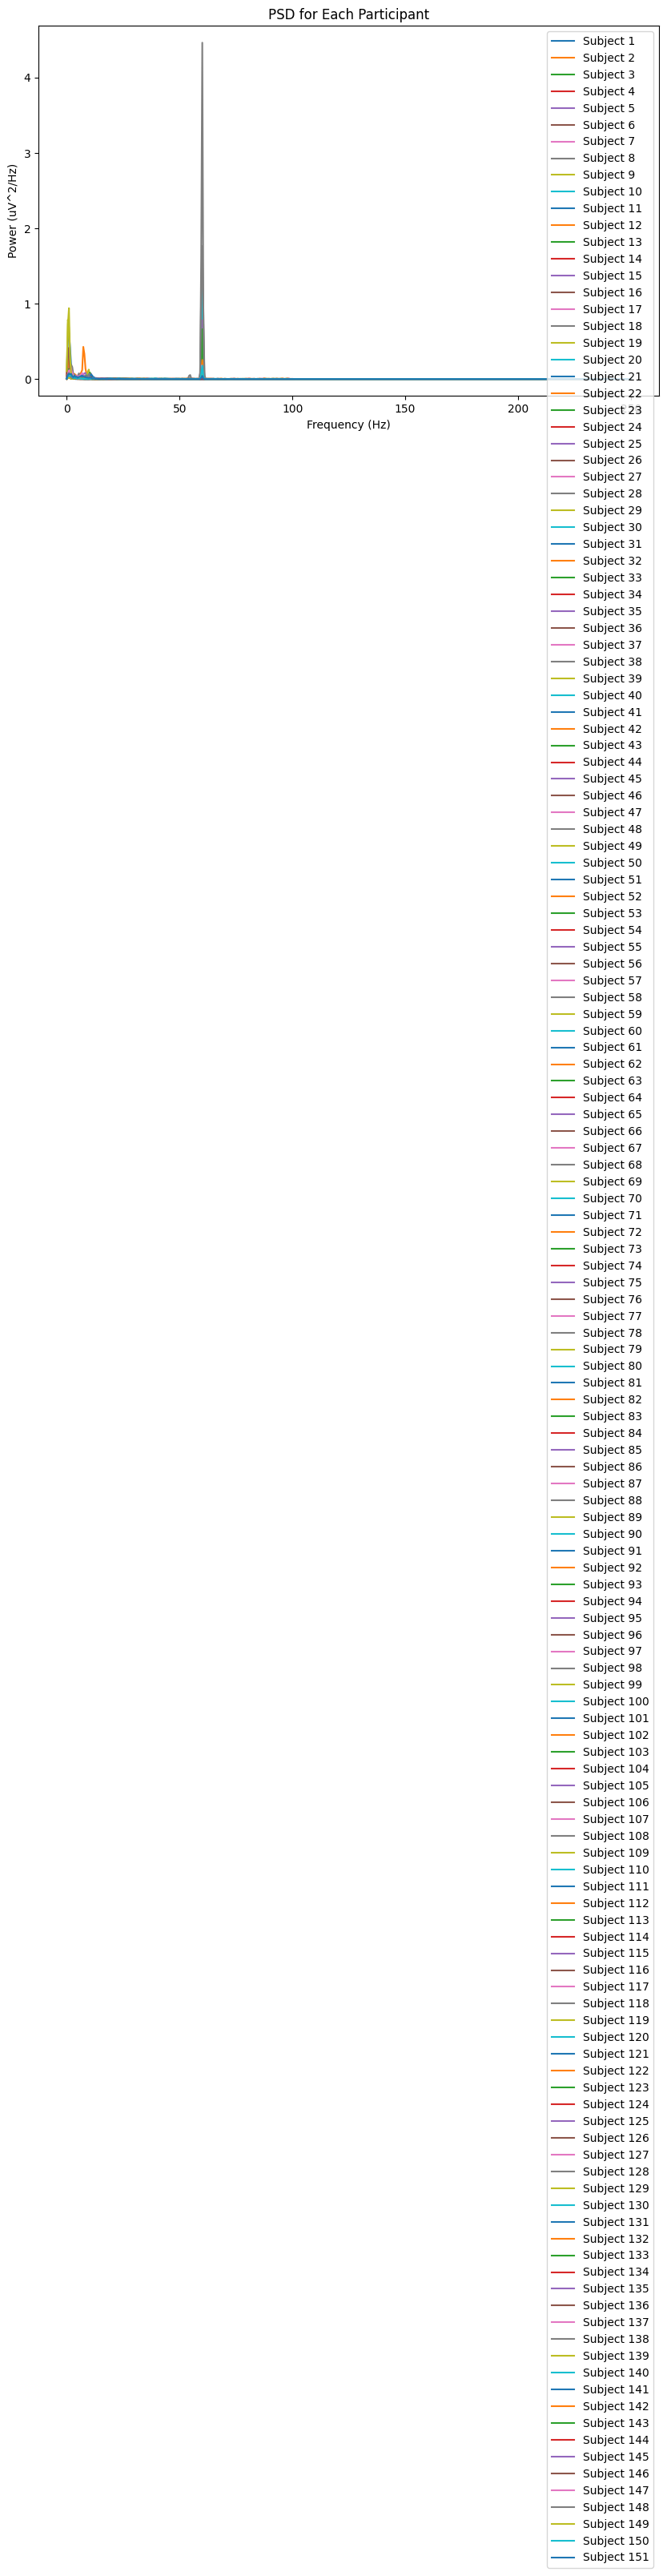

In [28]:
plt.figure(figsize=(10,6))


for i, subj_psd in enumerate(all_subject_psd):
    plt.plot(freqs, subj_psd, label=f"Subject {i+1}")


plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (uV^2/Hz)")
plt.title("PSD for Each Participant")
plt.legend()
plt.show()


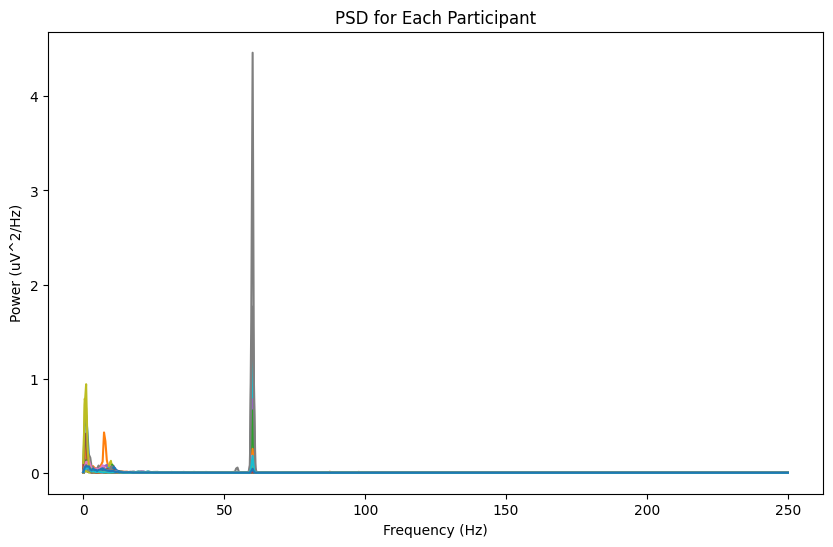

In [29]:
plt.figure(figsize=(10,6))


for subj_psd in all_subject_psd:
    plt.plot(freqs, subj_psd)


plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (uV^2/Hz)")
plt.title("PSD for Each Participant")
plt.show()


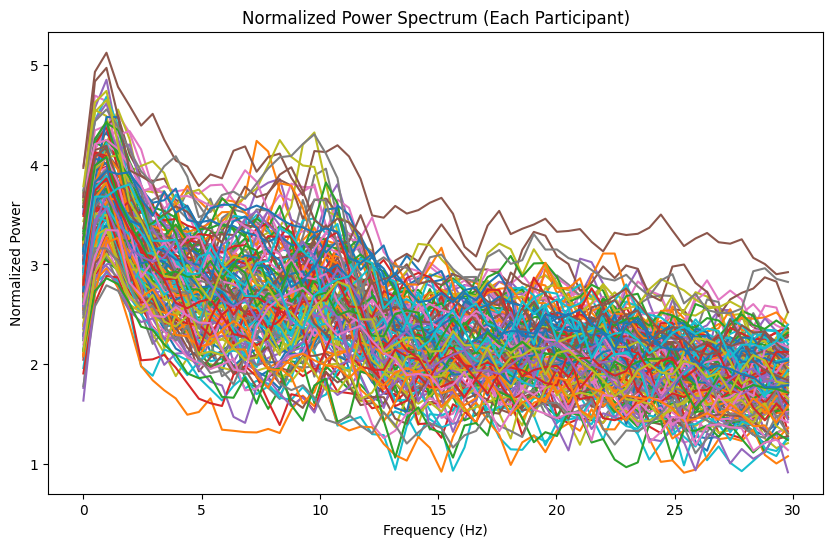

In [30]:
alpha_mask = (freqs >= 0) & (freqs <= 30)


plt.figure(figsize=(10,6))


for subj_psd in all_subject_psd:


    eps = 1e-12
    log_psd = np.log10(subj_psd + eps)


    # baseline = mean across all frequencies
    baseline = np.mean(log_psd)
    log_psd_norm = log_psd - baseline


    plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])


plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Normalized Power Spectrum (Each Participant)")
plt.show()


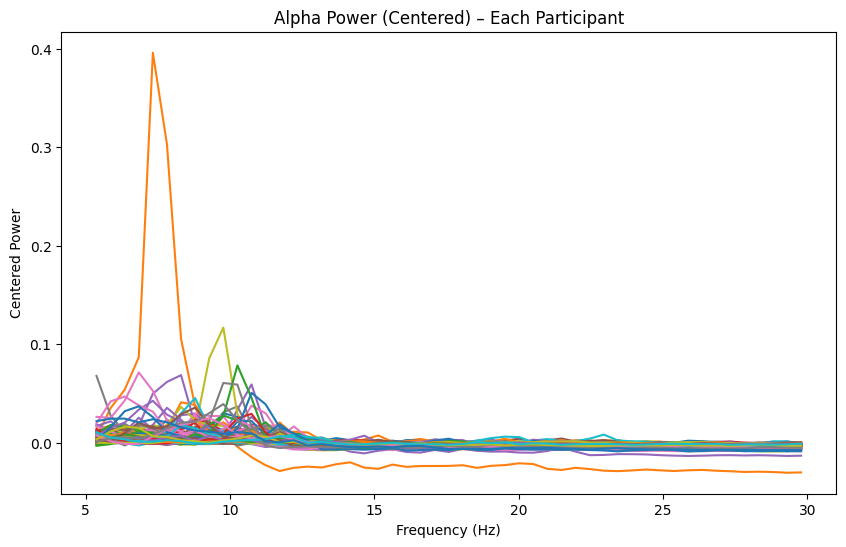

In [31]:
alpha_mask = (freqs >= 5) & (freqs <= 30)


plt.figure(figsize=(10,6))


for subj_psd in all_subject_psd:


    alpha_power = subj_psd[alpha_mask]
    alpha_power_centered = alpha_power - np.mean(alpha_power)


    plt.plot(freqs[alpha_mask], alpha_power_centered)


plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Alpha Power (Centered) – Each Participant")
plt.show()


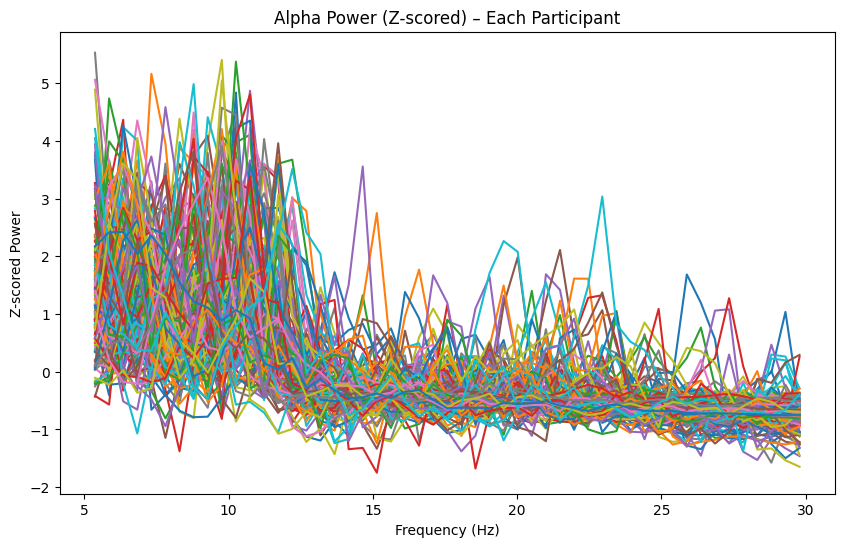

In [32]:
plt.figure(figsize=(10,6))


for subj_psd in all_subject_psd:


    alpha_power = subj_psd[alpha_mask]
    alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)


    plt.plot(freqs[alpha_mask], alpha_power_z)


plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Alpha Power (Z-scored) – Each Participant")
plt.show()


In [33]:
alpha_mask = (freqs >= 5) & (freqs <= 30)


# frequencies where we want error bars
target_freqs = [8, 10, 12]


means = []
cis = []


for f in target_freqs:


    # find closest frequency index
    idx = np.argmin(np.abs(freqs - f))


    # collect power from every participant at that frequency
    values = np.array([subj[idx] for subj in all_subject_psd])


    mean = np.mean(values)
    sem = stats.sem(values)


    # 95% confidence interval
    ci = sem * stats.t.ppf((1 + 0.65) / 2., len(values)-1)


    means.append(mean)
    cis.append(ci)



In [34]:
all_subject_psd = np.vstack(all_subject_psd)

group_psd_aces = np.mean(all_subject_psd, axis=0)

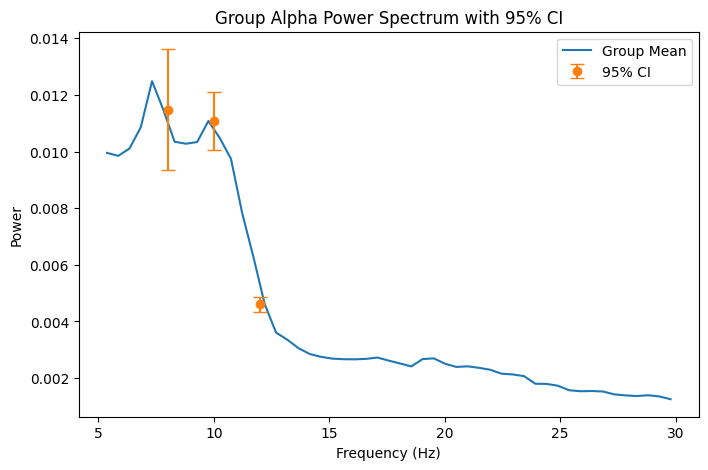

In [35]:
plt.figure(figsize=(8,5))


# group line
plt.plot(freqs[alpha_mask], group_psd_aces[alpha_mask], label="Group Mean")


# error bars
plt.errorbar(target_freqs, means, yerr=cis, fmt='o', capsize=5, label="95% CI")


plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum with 95% CI")
plt.legend()
plt.show()


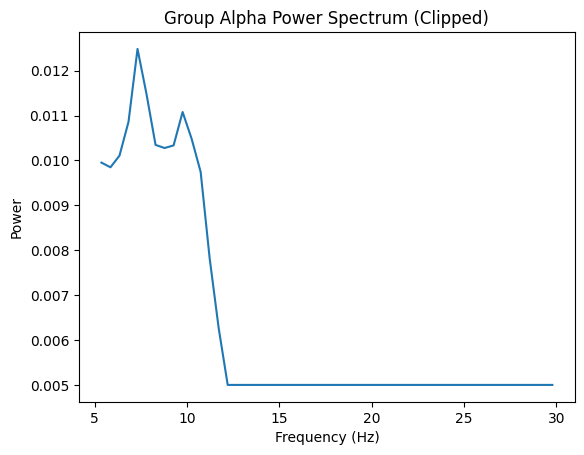

In [36]:
import numpy as np
import matplotlib.pyplot as plt


# Clip power values to desired range
clipped_psd = np.clip(group_psd_aces[alpha_mask], 0.005, 0.030)

# Plot
plt.plot(freqs[alpha_mask], clipped_psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum (Clipped)")
plt.show()

# Better Version ACES

In [37]:
eps = 1e-12
log_psd = np.log10(group_psd_aces + eps)

In [38]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm = log_psd - baseline

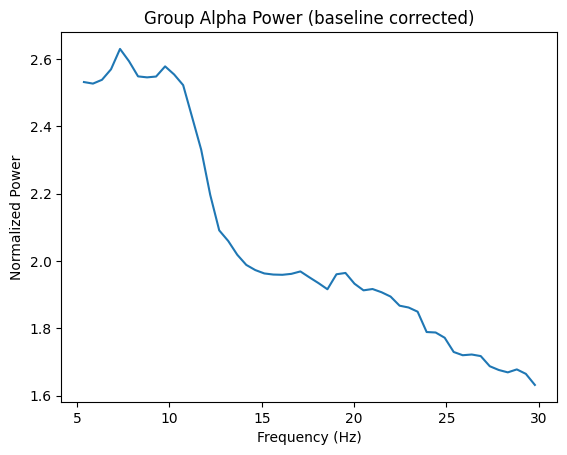

In [39]:

plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

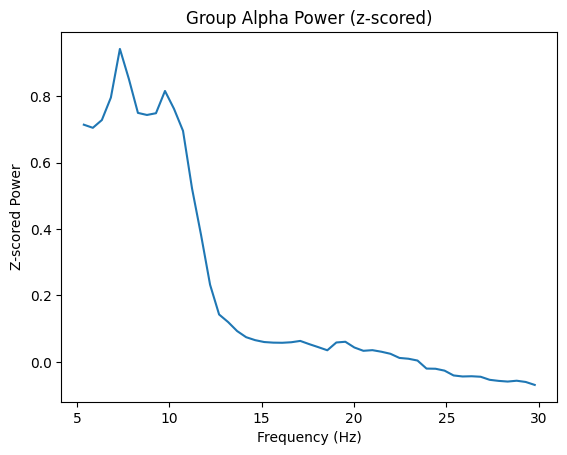

In [40]:
psd_mean = np.mean(group_psd_aces)
psd_std = np.std(group_psd_aces)
psd_z = (group_psd_aces - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

### 2nd Version

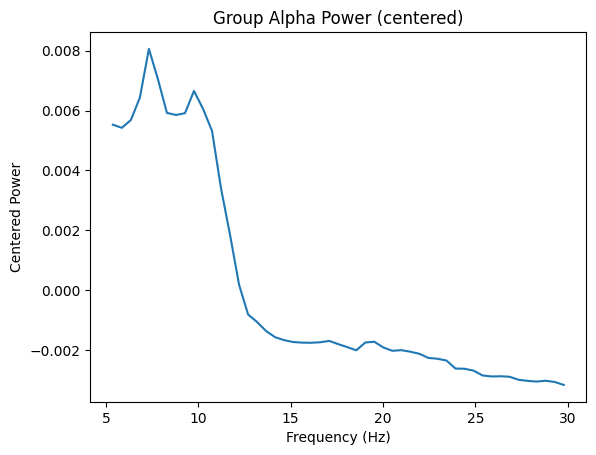

In [41]:


alpha_power_aces = group_psd_aces[alpha_mask]
alpha_power_centered_aces = alpha_power_aces - np.mean(alpha_power_aces)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_aces)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

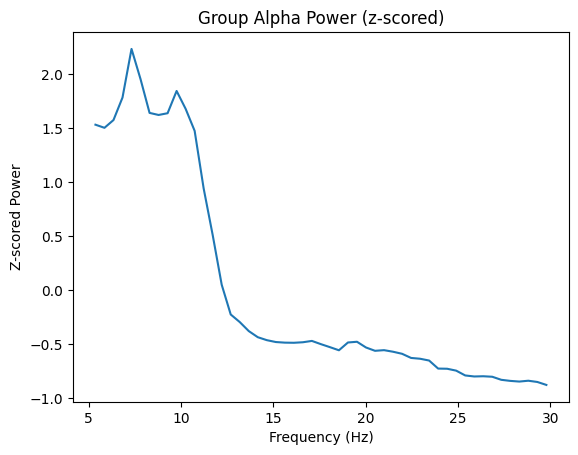

In [42]:
alpha_power_ace = group_psd_aces[alpha_mask]
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

plt.plot(freqs[alpha_mask], alpha_power_z_ace)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# Together Eyes Closed

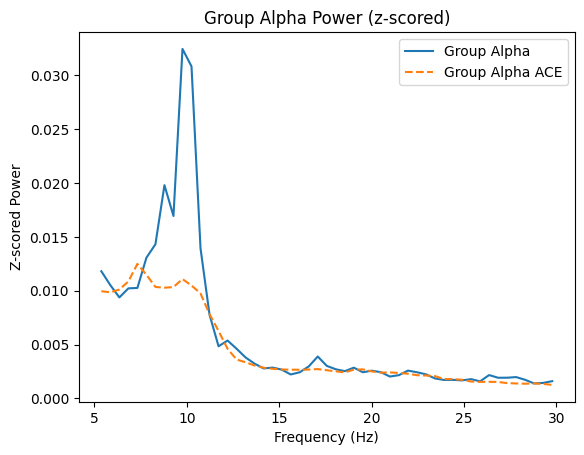

In [43]:
import matplotlib.pyplot as plt
import numpy as np


# First line
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

# Second line (ACE)
alpha_power_ace = group_psd_aces[alpha_mask]  # replace this with actual ACE data if different
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_ace, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()

In [90]:
alpha_mask = (freqs >= 8) & (freqs <= 12)

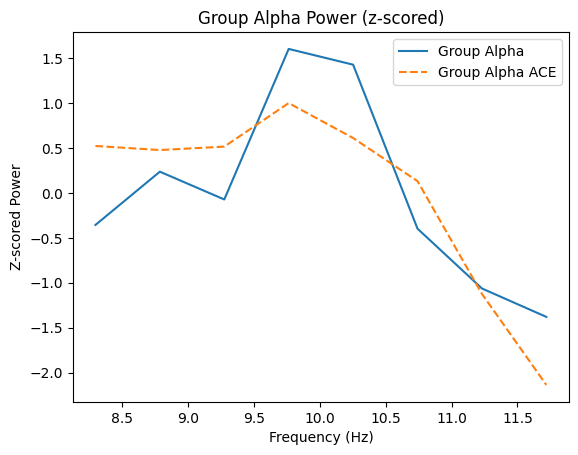

In [91]:
import matplotlib.pyplot as plt
import numpy as np



# First line
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

# Second line (ACE)
alpha_power_ace = group_psd_aces[alpha_mask]  # use the actual ACE data here
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_z_ace, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()

In [103]:
peak_freq_none = freqs[alpha_mask][np.argmax(alpha_power_z)]

In [104]:
print("Peak Alpha Frequency:", peak_freq_none, "Hz")

Peak Alpha Frequency: 9.765625 Hz


In [105]:
peak_freq = freqs[alpha_mask][np.argmax(alpha_power_z_ace)]

In [106]:
print("Peak Alpha Frequency:", peak_freq, "Hz")


Peak Alpha Frequency: 9.765625 Hz


# AUC

In [96]:
import numpy as np

In [107]:
auc_values = []

for subj_psd in all_subject_psd:
    eps = 1e-12
    log_psd = np.log10(subj_psd + eps)

    # choose the same normalization you used
    baseline = np.mean(log_psd)
    log_psd_norm = log_psd - baseline

    # restrict to frequency range (e.g., alpha or full)
    auc = np.trapz(log_psd_norm[alpha_mask], freqs[alpha_mask])
    
    auc_values.append(auc)

C:\Users\emros\AppData\Local\Temp\ipykernel_45196\81608799.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(log_psd_norm[alpha_mask], freqs[alpha_mask])


In [98]:
no_aces_files = glob.glob(os.path.join(no_aces, "*AveOverTrials.txt"))
aces_files = glob.glob(os.path.join(aces, "*AveOverTrials.txt"))

In [99]:
def compute_auc(files):
    aucs = []
    for f in files:
        data = np.genfromtxt(f, skip_header=1)
        signals = data[:,1:]

        elec_psds = []
        for e in range(signals.shape[1]):
            f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
            elec_psds.append(pxx)

        elec_psds = np.array(elec_psds)
        mean_psd = np.mean(elec_psds, axis=0)

        eps = 1e-12
        log_psd = np.log10(mean_psd + eps)
        baseline = np.mean(log_psd)
        log_psd_norm = log_psd - baseline

        auc = np.trapz(log_psd_norm[alpha_mask], freqs[alpha_mask])
        aucs.append(auc)

    return aucs

In [110]:
no_aces_auc = compute_auc(alpha_power_z)
aces_auc = compute_auc(alpha_power_z_ace)

TypeError: fname must be a string, a filehandle, a sequence of strings,
or an iterator of strings. Got <class 'numpy.float64'> instead.

In [101]:
print("No ACEs mean AUC:", np.mean(no_aces_auc))
print("ACEs mean AUC:", np.mean(aces_auc))

from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(no_aces_auc, aces_auc)
print("t =", t_stat, "p =", p_val)

No ACEs mean AUC: 8.759621112104725
ACEs mean AUC: 9.062852199562755
t = -1.0348897492781577 p = 0.3019955680661483


C:\Users\emros\AppData\Local\Temp\ipykernel_45196\33231385.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_aces_auc, aces_auc], labels=["No ACEs", "ACEs"])


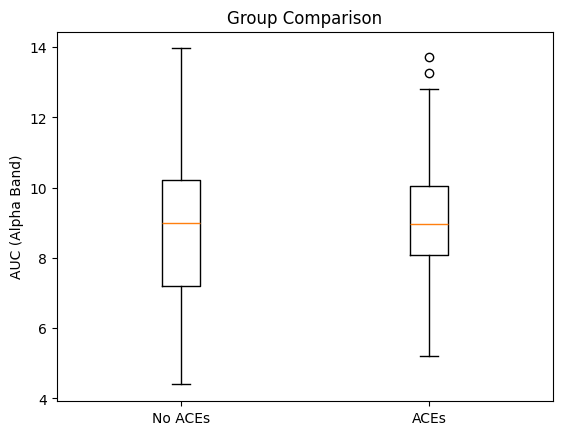

In [102]:
plt.figure()
plt.boxplot([no_aces_auc, aces_auc], labels=["No ACEs", "ACEs"])
plt.ylabel("AUC (Alpha Band)")
plt.title("Group Comparison")
plt.show()